# Inciso 8

### Librerías.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

### Rutas y constantes.

In [2]:
carpeta = Path("data")
lagos = ["atitlan", "amatitlan"]
umbral_alto = 10
umbral_persistencia = 60

Para el siguiente análisis se considerará alto si tiene un índice de cianobacteria de 10 $\mu g/L$ o más. El criterio fue obtenido del siguiente link
https://www.miteco.gob.es/content/dam/miteco/es/agua/formacion/05_Ponencia_Caridad_de_Hoyos_web_tcm30-214832.pdf

### Extracción de datos.

In [3]:
resultados_finales = []

for lago in lagos:
    carpeta = Path("data") / lago
    rutas = sorted(carpeta.glob(f"{lago}_*_indices.tif"))
    rasters, fechas = [], []
    for ruta in rutas:
        with rasterio.open(ruta) as src:
            arr = src.read(1).astype("float32")

        rasters.append(arr)
        fechas.append(ruta.stem.replace(f"{lago}_", "").replace("_indices", ""))

    
    valores = np.concatenate([arr[np.isfinite(arr)] for arr in rasters])
    
    for fecha, arr in zip(fechas, rasters):
        validos = np.isfinite(arr)
        altos = validos & (arr >= umbral_alto)
        n_validos, n_altos = validos.sum(), altos.sum()
        resultados_finales.append({"lago": lago.capitalize(), "fecha": fecha, "pixeles_validos": n_validos,
                                   "pixeles_altos": n_altos, "porcentaje_alto": n_altos / n_validos * 100 if n_validos > 0 else np.nan,
                                   "umbral": umbral_alto})

df_81 = pd.DataFrame(resultados_finales)
df_81["fecha"] = pd.to_datetime(df_81["fecha"])
df_81 = df_81.sort_values(["lago", "fecha"])
df_81.head()

,lago,fecha,pixeles_validos,pixeles_altos,porcentaje_alto,umbral
11,Amatitlan,2025-01-28,36896,12,0.032524,10
12,Amatitlan,2025-04-15,36473,245,0.671730,10
13,Amatitlan,2025-04-28,18987,235,1.237689,10
14,Amatitlan,2025-11-24,18901,729,3.856939,10
15,Amatitlan,2026-01-08,36928,2627,7.113843,10


### 8.1) Gráfica de acumulación.

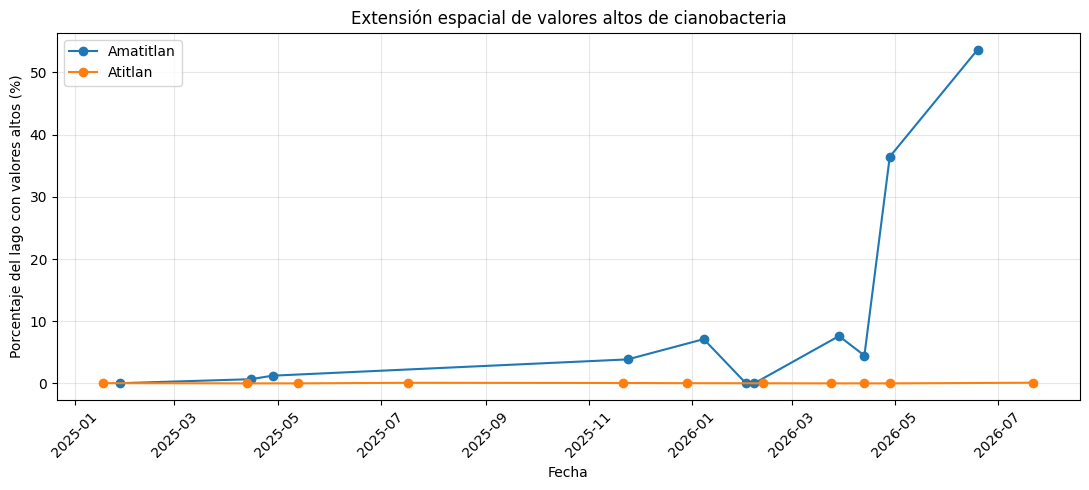

In [4]:
plt.figure(figsize=(11, 5))
for lago, datos in df_81.groupby("lago"):
    plt.plot(datos["fecha"], datos["porcentaje_alto"], marker="o", label=lago)
plt.xlabel("Fecha")
plt.ylabel("Porcentaje del lago con valores altos (%)")
plt.title("Extensión espacial de valores altos de cianobacteria")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Amatitlán suele mantener zonas con altos niveles de cianobacterias, mientras que Atitlán no parece presentar, por el momento, este tipo de zonas.

### Zonas persistentes de acumulación.

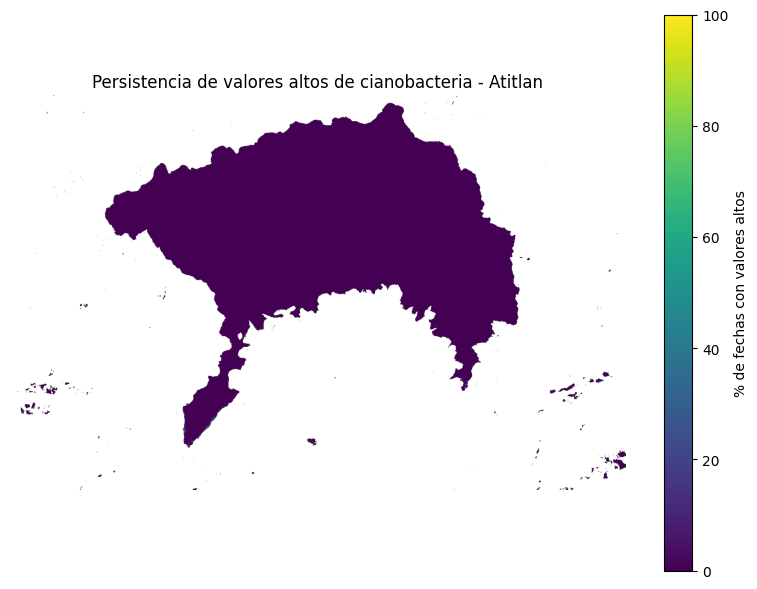

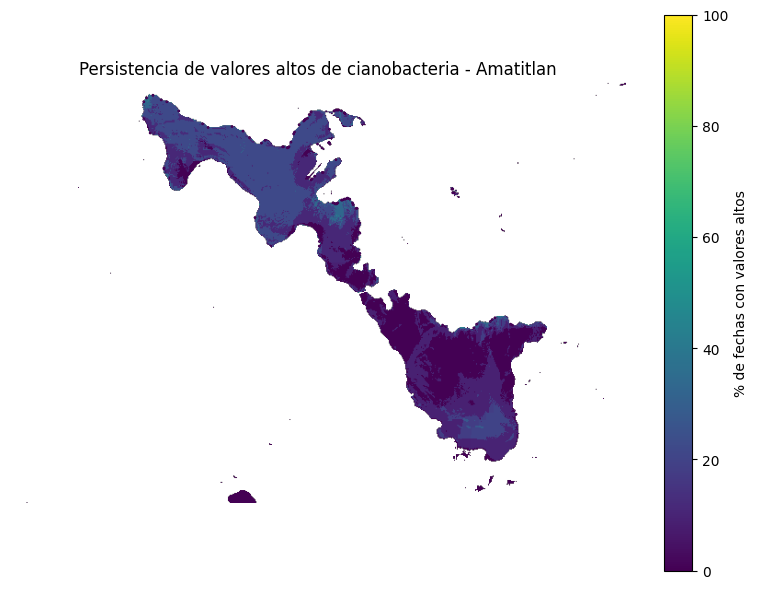

In [5]:
for lago in lagos:

    # Rutas
    carpeta = Path("data") / lago
    rutas = sorted(carpeta.glob(f"{lago}_*_indices.tif"))
    rasters = []

    #Extrayendo la información de las carpetas
    for ruta in rutas:
        with rasterio.open(ruta) as src:
            arr = src.read(1).astype("float32")
        rasters.append(arr)

    # Conteos y umbrales
    valores = np.concatenate([arr[np.isfinite(arr)] for arr in rasters])
    conteo_alto = np.zeros(rasters[0].shape, dtype=np.int32)
    conteo_valido = np.zeros(rasters[0].shape, dtype=np.int32)

    # Extrayendo píxeles válidos
    for arr in rasters:
        validos = np.isfinite(arr)
        altos = validos & (arr >= umbral_alto)
        conteo_alto += altos
        conteo_valido += validos

    # Calculando persistencias
    persistencia = np.full(rasters[0].shape, np.nan, dtype="float32")
    mascara = conteo_valido > 0
    persistencia[mascara] = conteo_alto[mascara] / conteo_valido[mascara] * 100
    zonas_persistentes = persistencia >= umbral_persistencia

    # Gráfico
    plt.figure(figsize=(8, 6))
    im = plt.imshow(persistencia, vmin=0, vmax=100)
    plt.colorbar(im, label="% de fechas con valores altos")
    plt.contour(zonas_persistentes, levels=[0.5], linewidths=1.5)
    plt.title(f"Persistencia de valores altos de cianobacteria - {lago.capitalize()}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

En el caso del lago de Atitlán, actualmente no se presentan zonas con altos niveles de cianobacterias (mayor a 10 $mu g/L$), aunque en el inciso 5 se presenciaron que las zonas más afectadas son las orillas cercanas a pueblos.
En el caso del lago de Amatitlán, las zonas más afectadas también son las conectadas a los pueblos, pero en especial la zona norte, donde se tiene la mayor cantidad de urbanización. Este lago zonas con porcentajes más altos que el de Atitlán.